In [ ]:
import pandas as pd
import glob as glob
from Bio.Seq import Seq
import os
import numpy as np
from Bio import motifs


In [47]:
files =glob.glob('/data2st1/junyi/scenic/mouse/motif/singletons/*')

In [48]:
outdir = '/data2st1/junyi/scenic/mouse/motif/merged_cluster'

In [49]:
tbffile = '/data2st1/junyi/scenic/mouse/motif/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl'

In [50]:
TFoutdir = '/data2st1/junyi/output/atac1112/snregulation/'

In [51]:
df_important_TF = pd.read_csv(f'/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/significant_TFlist.csv',header=None)

In [52]:
df_important_TF.columns=['TF']

In [53]:
df_tbffile = pd.read_csv(tbffile, sep='\t')

/tmp/ipykernel_3818014/313275177.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tbffile = pd.read_csv(tbffile, sep='\t')


In [ ]:
df = df_tbffile
motif_similarity_fdr = 0.001,
orthologous_identity_threshold  = 0.0
df.rename(columns={'#motif_id':"MotifID",
                    'gene_name':"TF",
                    'motif_similarity_qvalue': "MotifSimilarityQvalue",
                    'orthologous_identity': "OrthologousIdentity",
                    'description': "Annotation" }, inplace=True)
df = df[(df["MotifSimilarityQvalue"] <= motif_similarity_fdr) &
        (df["OrthologousIdentity"] >= orthologous_identity_threshold)]


In [ ]:
df_direct_annot = df[df['Annotation'] == 'gene is directly annotated']
#df_direct_annot = df_direct_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()


In [128]:
df_direct_annot

,MotifID,motif_name,motif_description,source_name,source_version,TF,MotifSimilarityQvalue,similar_motif_id,similar_motif_description,OrthologousIdentity,orthologous_gene_name,orthologous_species,Annotation
183,c2h2_zfs__M0369,M0369,ENSMUSG00000000317,c2h2_zfs,0.90,Bcl6b,0.0,None,None,1.0,None,None,gene is directly annotated
184,c2h2_zfs__M0373,M0373,ENSMUSG00000022228,c2h2_zfs,0.90,Zscan26,0.0,None,None,1.0,None,None,gene is directly annotated
185,c2h2_zfs__M0385,M0385,ENSMUSG00000028890,c2h2_zfs,0.90,Mtf1,0.0,None,None,1.0,None,None,gene is directly annotated
186,c2h2_zfs__M0393,M0393,ENSMUSG00000033863,c2h2_zfs,0.90,Klf9,0.0,None,None,1.0,None,None,gene is directly annotated
189,c2h2_zfs__M0400,M0400,ENSMUSG00000041703,c2h2_zfs,0.90,Zic5,0.0,None,None,1.0,None,None,gene is directly annotated
...,...,...,...,...,...,...,...,...,...,...,...,...,...
251819,transfac_public__M00532,M00532,V$RP58_01: RP58,transfac_public,7.0,Zbtb18,0.0,None,None,1.0,None,None,gene is directly annotated
251825,metacluster_71.11,M00538,V$HTF_01: HTF (XBP1),transfac_public,7.0,Xbp1,0.0,None,None,1.0,None,None,gene is directly annotated
251826,metacluster_57.3,M00539,V$ARNT_02: Arnt,transfac_public,7.0,Arnt,0.0,None,None,1.0,None,None,gene is directly annotated
251904,metacluster_198.2,M00615,V$MYCMAX_03: c-Myc:Max,transfac_public,7.0,Max,0.0,None,None,1.0,None,None,gene is directly annotated


In [57]:
dict_id2tf = dict(zip(df_direct_annot['MotifID'], df_direct_annot['TF']))

In [ ]:
motif_similarity_annot = df[df['Annotation'].str.contains('similar') & ~df['Annotation'].str.contains('orthologous')]
#motif_similarity_annot = motif_similarity_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()


In [59]:
direct_motif_TFs = df_direct_annot[df_direct_annot.TF.isin(df_important_TF.TF)]

In [60]:
direct_motif_TFs = direct_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()


In [127]:
direct_motifs = []
names = []
parsed_TFs= []
for f in files:
    bn = os.path.basename(f).removesuffix('.cb')
    if bn not in direct_motif_TFs['MotifID'].values:
        #print(f"Skipping {bn} as it is not in the important TF list.")
        continue
    tf_tmp = direct_motif_TFs[direct_motif_TFs['MotifID'] == bn].TF.values[0]
    try:
        with open(f) as handle:
            m = motifs.read(handle, "ClusterBuster")
            direct_motifs.append(m)
            names.append(bn)
            parsed_TFs.append(tf_tmp)
            if 'MA0859.1' in record.name:
                print("here")

    except ValueError:
        with open(f) as handle:
            records = motifs.parse(handle, "ClusterBuster")
            for record in records:
                if 'MA0859.1' in record.name:
                    print("here")
                record.name = bn+"#"+record.name
                direct_motifs.append(record)
                names.append(record.name)
                parsed_TFs.append(tf_tmp)


In [116]:
mapdict = dict(zip(names, parsed_TFs))

In [214]:
extended_motif_TFs = motif_similarity_annot[motif_similarity_annot.TF.isin(df_important_TF.TF)]
extended_motif_TFs = extended_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

In [264]:
TOBIAS_Rsults = glob.glob(f'/data2st2/junyi/output/atac1112/tobiasbam/*/*.bw/bindetect_results.xlsx')

In [450]:
df_tobias

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,MC_MW_pvalue,MC_MW_highlighted,ctname,TFID,TF,abs_change,TFexpand
0,metacluster_29.1jaspar__MA0519.1_None,metacluster_29.1#jaspar__MA0519.1,None,C_metacluster_29.2#swissregulon__mm__Stat5b,22972,0.41573,5414,0.43511,5683,-0.00852,9.557620e-22,False,AMY_MOL-2,metacluster_29.1,Stat5a,0.00852,[Stat5a]
1,metacluster_29.1swissregulon__hs__STAT5B_None,metacluster_29.1#swissregulon__hs__STAT5B,None,C_metacluster_29.1#swissregulon__hs__STAT5B,16583,0.41064,3733,0.42773,3925,-0.00223,4.981700e-04,False,AMY_MOL-2,metacluster_29.1,Stat5a,0.00223,[Stat5a]
2,metacluster_29.1transfac_public__M00460_None,metacluster_29.1#transfac_public__M00460,None,C_metacluster_29.1#swissregulon__hs__STAT5B,10332,0.41403,2408,0.43565,2594,-0.00879,6.405580e-17,False,AMY_MOL-2,metacluster_29.1,Stat5a,0.00879,[Stat5a]
3,metacluster_21.5swissregulon__mm__Hsf1_None,metacluster_21.5#swissregulon__mm__Hsf1,None,C_metacluster_21.5#hocomoco__HSF1_MOUSE.H11MO.0.A,10948,0.40234,2487,0.41449,2570,0.01591,1.421530e-29,False,AMY_MOL-2,metacluster_21.5,Hsf1,0.01591,[Hsf1]
4,metacluster_21.5swissregulon__sacCer__HSF1_None,metacluster_21.5#swissregulon__sacCer__HSF1,None,C_metacluster_21.5#scertf__pachkov.HSF1,19427,0.37836,4183,0.39646,4475,0.00664,6.315110e-11,False,AMY_MOL-2,metacluster_21.5,Hsf1,0.00664,[Hsf1]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4268,metacluster_90.6elemento__CAAGGTC_None,metacluster_90.6#elemento__CAAGGTC,None,C_metacluster_90.4#taipale_cyt_meth__NR5A2_NYC...,9218,0.41638,2281,0.45149,2580,-0.03006,1.795950e-47,False,AMY_MOL-2,metacluster_90.6,"Esrra, Esrrg, Esrrb",0.03006,"[Esrra, Esrrg, Esrrb]"
4269,metacluster_90.6elemento__CAAGGTCA_None,metacluster_90.6#elemento__CAAGGTCA,None,C_metacluster_121.1#jaspar__MA1996.1,3808,0.37627,852,0.42045,1041,-0.06861,3.482770e-63,True,AMY_MOL-2,metacluster_90.6,"Esrra, Esrrg, Esrrb",0.06861,"[Esrra, Esrrg, Esrrb]"
4270,metacluster_90.6elemento__CCAAGGTC_None,metacluster_90.6#elemento__CCAAGGTC,None,C_metacluster_90.4#taipale_cyt_meth__NR5A2_NYC...,2902,0.45706,802,0.49445,926,-0.02612,4.625940e-29,False,AMY_MOL-2,metacluster_90.6,"Esrra, Esrrg, Esrrb",0.02612,"[Esrra, Esrrg, Esrrb]"
4271,metacluster_90.6cisbp__M03401_None,metacluster_90.6#cisbp__M03401,None,C_metacluster_90.6#cisbp__M03401,16243,0.45206,4259,0.48390,4751,-0.02648,9.894770e-51,False,AMY_MOL-2,metacluster_90.6,"Esrra, Esrrg, Esrrb",0.02648,"[Esrra, Esrrg, Esrrb]"


In [451]:
results = pd.DataFrame()
full = pd.DataFrame()
for file in TOBIAS_Rsults:
    print(file)
    df_tobias = pd.read_excel(file)
    ctname = file.split('/')[-2].replace('_MC_footprints.bw','')
    region = ctname[:3]
    df_tobias['ctname'] = ctname
    df_tobias['TFID'] = df_tobias['name'].str.split('#').str[0]
    df_direct_annot_map = dict(zip(df_direct_annot['MotifID'], df_direct_annot['TF']))
    df_tobias['TF']= df_tobias['name'].map(mapdict)
    df_tobias.dropna(inplace=True)
    df_tobias['abs_change'] = df_tobias['MC_MW_change'].abs()
    df_tobias.sort_values(by='abs_change', ascending=False, inplace=True)
    df_tobias.drop_duplicates(subset=['TFID','TF'], inplace=True)

    df_tobias["TFexpand"] = df_tobias["TF"].str.split(",\s*")  # split by comma + optional space
    df_expanded = df_tobias.explode("TFexpand").reset_index(drop=True)

    # df_expanded
    df_expanded_mean = df_expanded.groupby('TFexpand').mean()
    df_expanded_mean['TF'] = df_expanded_mean.index
    df_expanded_mean['ctname'] = ctname
    df_expanded_mean['Region'] = region
    results = pd.concat([results, df_expanded_mean], axis=0)

    df_expanded

/data2st2/junyi/output/atac1112/tobiasbam/PFC/PFC_PFC_Sst_Chodl_GABA_MC_footprints.bw/bindetect_results.xlsx


/tmp/ipykernel_3818014/2942274546.py:21: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_expanded_mean = df_expanded.groupby('TFexpand').mean()


/data2st2/junyi/output/atac1112/tobiasbam/PFC/PFC_MOL-1_MC_footprints.bw/bindetect_results.xlsx


/tmp/ipykernel_3818014/2942274546.py:21: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_expanded_mean = df_expanded.groupby('TFexpand').mean()


/data2st2/junyi/output/atac1112/tobiasbam/PFC/PFC_PFC_L5_NP_Glut_MC_footprints.bw/bindetect_results.xlsx


...

/tmp/ipykernel_3818014/2942274546.py:21: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_expanded_mean = df_expanded.groupby('TFexpand').mean()


/data2st2/junyi/output/atac1112/tobiasbam/AMY/AMY_AMY_Piezo2_Cpa6_Glut_MC_footprints.bw/bindetect_results.xlsx


/tmp/ipykernel_3818014/2942274546.py:21: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_expanded_mean = df_expanded.groupby('TFexpand').mean()


/data2st2/junyi/output/atac1112/tobiasbam/AMY/AMY_MOL-2_MC_footprints.bw/bindetect_results.xlsx


/tmp/ipykernel_3818014/2942274546.py:21: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_expanded_mean = df_expanded.groupby('TFexpand').mean()


In [452]:
results['Direction'] = results['MC_MW_change'].apply(lambda x: 'Up' if x > 0 else 'Down')
results['Sex'] = 'M'
results['Gene'] = results['TF']
results['ctname'] = results['ctname'].str.replace('HIP','HPF')
results["Neurotransmitter"] =  results["ctname"].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
results['Region Subclass'] = results['ctname']
results['log2FC'] = results['MC_MW_change']
results['FDR'] = results['MC_MW_pvalue']
results['Subclass'] = results['Region Subclass'].str[4:].replace('HIP','HPF')
results['Region'] = results['Region'].str.replace('HIP','HPF')
results['status'] = results['Direction']
results['celltype.L2'] = results['Subclass']

In [453]:
results

,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,MC_MW_pvalue,MC_MW_highlighted,abs_change,TF,...,Direction,Sex,Gene,Neurotransmitter,Region Subclass,log2FC,FDR,Subclass,status,celltype.L2
TFexpand,,,,,,,,,,,,,,,,,,,,,
Arid3a,7807.000000,1.224060,567.666667,1.252477,553.666667,0.055703,1.071523e-43,0.00,0.055703,Arid3a,...,Up,M,Arid3a,GABA,PFC_PFC_Sst_Chodl_GABA,0.055703,1.071523e-43,PFC_Sst_Chodl_GABA,Up,PFC_Sst_Chodl_GABA
Arnt,2973.428571,3.218657,957.857143,3.309923,940.000000,0.034879,1.981657e-04,0.00,0.034879,Arnt,...,Up,M,Arnt,GABA,PFC_PFC_Sst_Chodl_GABA,0.034879,1.981657e-04,PFC_Sst_Chodl_GABA,Up,PFC_Sst_Chodl_GABA
Arnt2,5083.500000,2.179525,1005.500000,2.318970,1045.000000,0.007470,2.870590e-20,0.00,0.025990,Arnt2,...,Up,M,Arnt2,GABA,PFC_PFC_Sst_Chodl_GABA,0.007470,2.870590e-20,PFC_Sst_Chodl_GABA,Up,PFC_Sst_Chodl_GABA
Arntl,2883.750000,3.126423,910.000000,3.145135,874.500000,0.060065,7.515778e-26,0.25,0.060065,Arntl,...,Up,M,Arntl,GABA,PFC_PFC_Sst_Chodl_GABA,0.060065,7.515778e-26,PFC_Sst_Chodl_GABA,Up,PFC_Sst_Chodl_GABA
Ascl1,7012.500000,2.209900,1600.500000,2.376020,1666.000000,0.007880,2.736280e-77,1.00,0.094150,Ascl1,...,Up,M,Ascl1,GABA,PFC_PFC_Sst_Chodl_GABA,0.007880,2.736280e-77,PFC_Sst_Chodl_GABA,Up,PFC_Sst_Chodl_GABA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zfp143,24013.500000,0.611650,7767.500000,0.643355,8452.000000,-0.021570,5.940100e-37,0.00,0.021570,Zfp143,...,Down,M,Zfp143,NN,AMY_MOL-2,-0.021570,5.940100e-37,MOL-2,Down,MOL-2
Zfp148,38147.000000,0.498290,10890.000000,0.538380,12322.000000,-0.046250,2.582270e-98,1.00,0.046250,Zfp148,...,Down,M,Zfp148,NN,AMY_MOL-2,-0.046250,2.582270e-98,MOL-2,Down,MOL-2
Zfp263,17466.000000,0.594055,5704.500000,0.634885,6349.500000,-0.041225,4.783240e-61,0.50,0.041225,Zfp263,...,Down,M,Zfp263,NN,AMY_MOL-2,-0.041225,4.783240e-61,MOL-2,Down,MOL-2


In [454]:
results=results[results.FDR <0.05]

In [455]:
results.to_csv(f'/data2st1/junyi/output/atac1112/tobias/tobias_TF_activity_summary_significant_TFs.csv')

In [456]:
results['nlogp'] = -np.log10(results['FDR'] + 1e-300) * np.sign(results['log2FC'])

/tmp/ipykernel_3818014/1019759776.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['nlogp'] = -np.log10(results['FDR'] + 1e-300) * np.sign(results['log2FC'])


In [457]:
results['Regulation'] = results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)


/tmp/ipykernel_3818014/3736920283.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Regulation'] = results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)


In [458]:
results['Regulation']=results['Regulation'].astype(float)

/tmp/ipykernel_3818014/2240312652.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Regulation']=results['Regulation'].astype(float)


Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


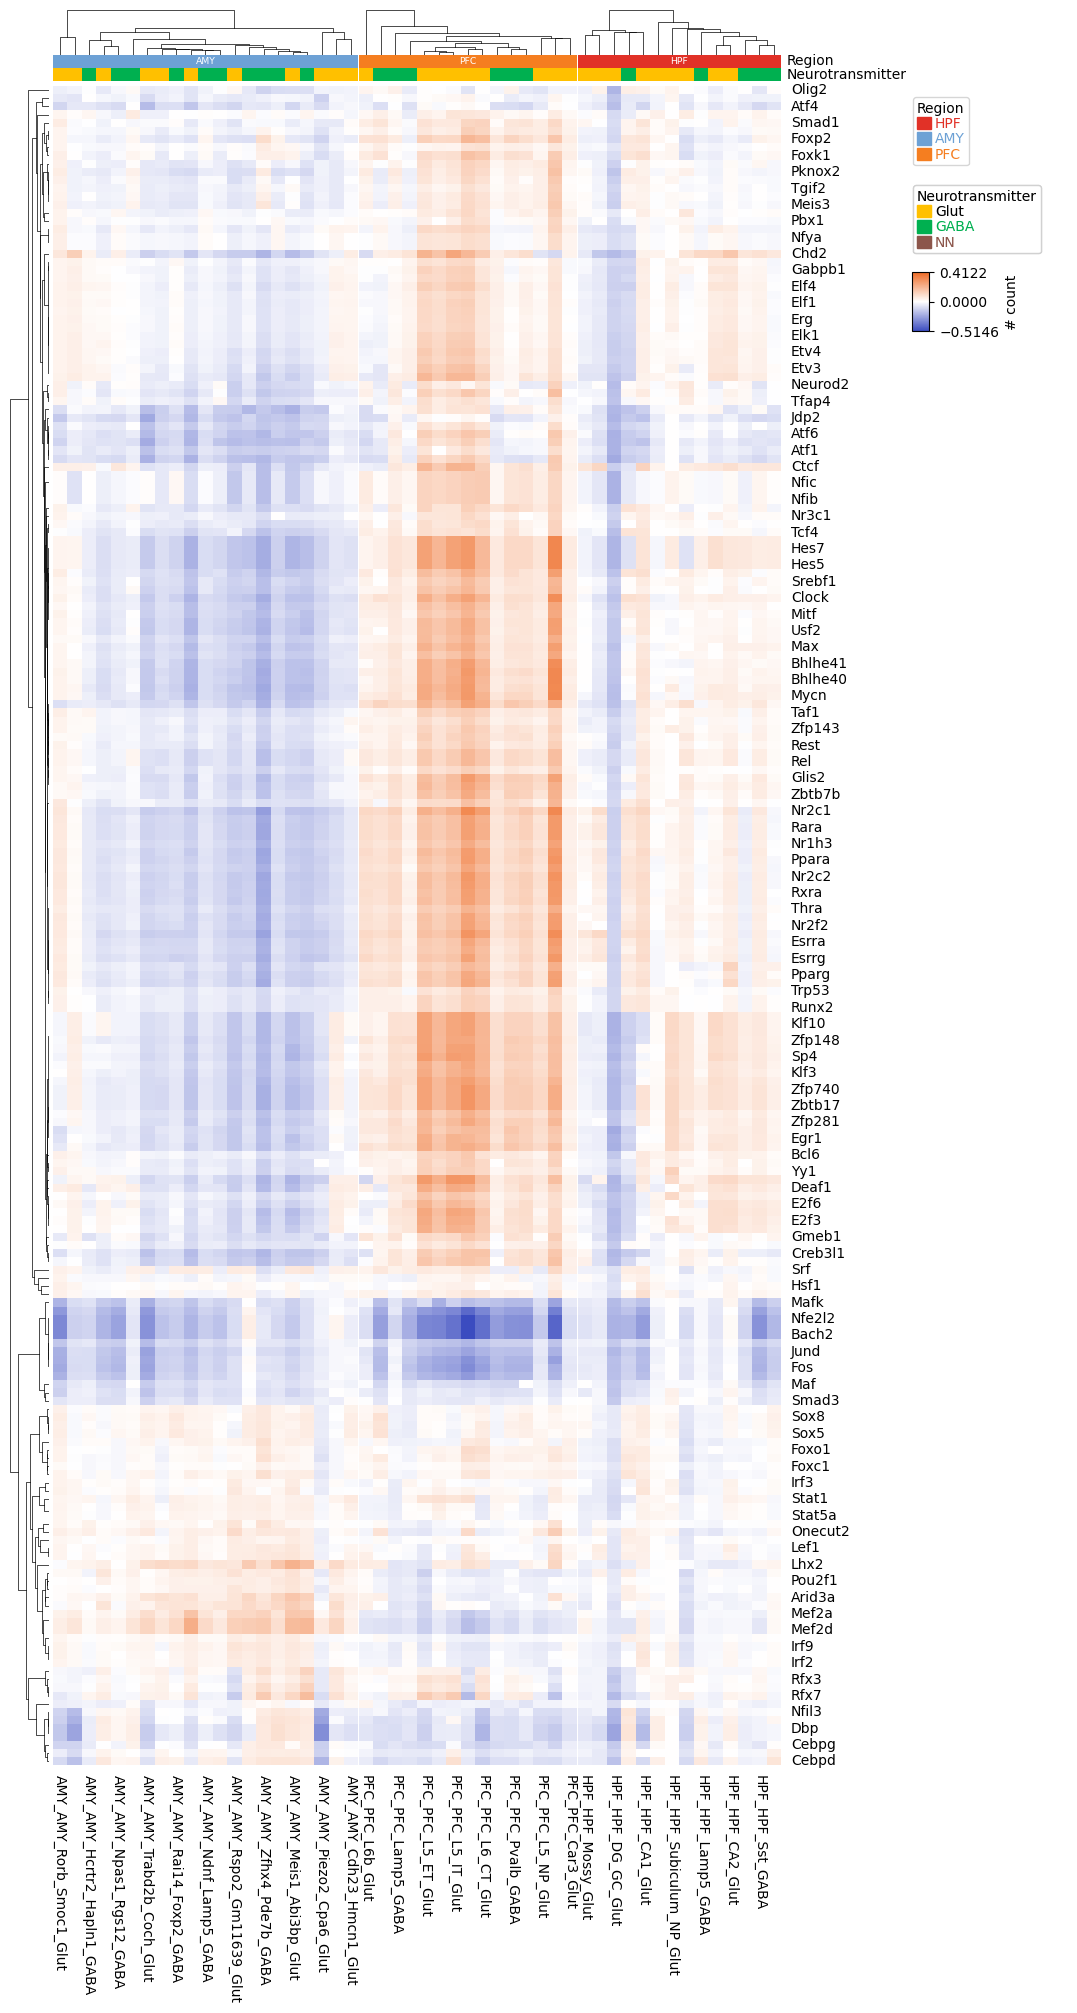

In [459]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PyComplexHeatmap as pch
from matplotlib.colors import LinearSegmentedColormap


# ---------------------------------------------------------
# 你的颜色
# ---------------------------------------------------------
region_colors = {
    "HPF": "#E13127",
    "AMY": "#6DA1D5",
    "PFC": "#F57E20",
}

nt_colors = {
    "Glut": "#FFC000",
    "GABA": "#00B050",
    "NN":   "#8c564b",
}


# ---------------------------------------------------------
# 主函数：绘制 TF × Region Subclass 热图
# ---------------------------------------------------------
def draw_tf_heatmap(df,value_col="Regulation", clipping=10,row_order=None, col_order=None):
    df = df.copy()
    if clipping:
        df[value_col] = df[value_col].clip(-1*clipping,clipping)  

    if col_order is not None:
    # Only keep columns that exist
        col_order_filtered = [c for c in col_order if c in mat.columns]
        mat = mat[col_order_filtered]

    # Apply custom TF/row order if provided
    if row_order is not None:
        row_order_filtered = [r for r in row_order if r in mat.index]
        mat = mat.loc[row_order_filtered]

    # ============================
    # 1. 构建矩阵
    # ============================
    mat = df.pivot_table(
        index="TF",
        columns="Region Subclass",
        values=value_col,
        aggfunc="mean"
    ).fillna(0)
    print("Checking columns...")

    mat = mat.replace([np.inf, -np.inf], np.nan).fillna(0)
    mat = mat.astype(float)
    mat = mat.replace([np.inf, -np.inf], np.nan)
    mat = mat.fillna(0)
    mat = mat.apply(pd.to_numeric, errors="coerce").fillna(0)


    mat = df.pivot_table(
    index="TF",
    columns="Region Subclass",
    values=value_col,
    aggfunc="mean"
    )   

    mat = mat.apply(pd.to_numeric, errors="coerce").fillna(0)

    # 1. Remove constant columns
    constant_cols = mat.columns[mat.apply(lambda x: x.nunique() <= 1)]
    print("Constant columns:", constant_cols.tolist())
    mat = mat.drop(columns=constant_cols)

    # # 2. Remove duplicate columns
    # mat_T = mat.T.drop_duplicates().T
    # removed_duplicates = set(mat.columns) - set(mat_T.columns)
    # print("Duplicate columns removed:", removed_duplicates)
    # mat = mat_T

    # 3. Final clean
    mat = mat.astype(float)
    assert np.isfinite(mat.values).all()
    # ============================
    # 2. 列注释 (Region + Neurotransmitter)
    # ============================
    col_meta = (
        df[["Region Subclass", "Region", "Neurotransmitter"]]
        .drop_duplicates()
        .set_index("Region Subclass")
        .loc[mat.columns]
    )

    # 按 region 排序列
    col_meta = col_meta.sort_values("Region")
    mat = mat[col_meta.index]

    region = col_meta["Region"]
    nt = col_meta["Neurotransmitter"]

    # ============================
    # 3. 行注释（可选：也可以不加）
    # ============================
    if "Category" in df.columns:
        row_meta = (
            df[["TF", "Category"]]
            .drop_duplicates()
            .set_index("TF")
            .loc[mat.index]
        )
        category = row_meta["Category"]
    else:
        category = None

    # ============================
    # 4. 创建顶部列注释
    # ============================
    col_ha = pch.HeatmapAnnotation(
        Region=pch.anno_simple(region, colors=region_colors, add_text=True),
        Neurotransmitter=pch.anno_simple(nt, colors=nt_colors, add_text=False),
        axis=1
    )

    # ============================
    # 5. 如果提供 Category，则加入左侧注释
    # ============================
    if category is not None:
        row_ha = pch.HeatmapAnnotation(
            Category=pch.anno_simple(category, add_text=False),
            axis=0
        )
    else:
        row_ha = None

    # ============================
    # 6. 颜色映射：蓝→白→橙，中心为0
    # ============================
    cmap = LinearSegmentedColormap.from_list(
        "blue_white_orange",
        ["#3B4CC0", "white", "#EE6A24"]
    )

    vmin = np.nanmin(mat.values)
    vmax = np.nanmax(mat.values)
    plt.figure(figsize=(10, 20))
    
    # print("Any NaN in columns? ", mat.isna().any())
    # print("Any inf? ", np.isinf(mat).any())

    # # 找出哪个 column 有 NaN / inf
    # print("Columns with NaN: ", mat.columns[mat.isna().any()].tolist())
    # print("Columns with inf: ", mat.columns[np.isinf(mat).any()].tolist())
    # ============================
    # 7. 绘制 Complex Heatmap
    # ============================
    cm = pch.ClusterMapPlotter(
        data=mat,
        top_annotation=col_ha,
        left_annotation=row_ha,
        col_split=region,      # 按 Region 分面
        row_cluster=True,
        col_cluster=True,
        row_dendrogram=True,
        col_dendrogram=True,
        cmap=cmap,
        col_split_order = ['AMY','PFC','HPF'],
        center=0,
        # col_order=col_order,        # pass user-defined order
        # row_order=row_order,        # pass user-defined order
        # col_cluster=False if col_order is not None else True,
        # row_cluster=False if row_order is not None else True,

        show_rownames=True,
        show_colnames=True,
        label="# count",
        rasterized=True
    )

    # # # 调整字体
    # if cm.ax_col_names is not None:
    #     for txt in cm.ax_col_names.texts:
    #         txt.set_rotation(90)
    #         txt.set_fontsize(7)

    # if cm.ax_row_names is not None:
    #     for txt in cm.ax_row_names.texts:
    #         txt.set_fontsize(6)

    plt.show()
    return cm
cm = draw_tf_heatmap(results[results.Neurotransmitter!='NN'],value_col="log2FC", clipping=30)

In [460]:
cm.data2d

Region Subclass,AMY_AMY_Cav1_Frmpd1_Glut,AMY_AMY_Zfhx4_Pde7b_GABA,AMY_AMY_Zfhx3_Glra1_Glut,AMY_AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Trabd2b_Coch_Glut,AMY_AMY_Tcf7l2_Gm20713_Glut,AMY_AMY_Rspo2_Gm11639_Glut,AMY_AMY_Rorb_Smoc1_Glut,AMY_AMY_Piezo2_Cpa6_Glut,AMY_AMY_Npas1_Rgs12_GABA,...,PFC_PFC_L6_IT_Glut,PFC_PFC_L5_IT_Glut,PFC_PFC_L5_NP_Glut,PFC_PFC_L5_ET_Glut,PFC_PFC_L4-5_IT_Glut,PFC_PFC_L2-3_IT_Glut,PFC_PFC_Car3_Glut,PFC_PFC_Sst_GABA,PFC_PFC_L6_CT_Glut,PFC_PFC_Vip_GABA
TF,,,,,,,,,,,,,,,,,,,,,
Arid3a,0.048490,0.085063,0.104643,0.101783,0.090113,0.083017,0.091403,0.007750,-0.037030,0.017790,...,0.024100,-0.044293,-0.037740,-0.087360,-0.058030,0.102570,0.026860,-0.003993,-0.062090,-0.038457
Arnt,-0.065637,-0.181786,-0.074789,-0.166307,-0.124044,-0.041649,-0.121746,0.024156,-0.096964,-0.036533,...,0.173591,0.219534,0.066547,0.234209,0.265993,0.272473,0.043521,0.084294,0.187526,0.051070
Arnt2,-0.044815,-0.133715,-0.065120,-0.113885,-0.089990,-0.039500,-0.091775,0.032830,-0.074900,-0.045095,...,0.098945,0.121430,0.054735,0.131170,0.169285,0.182160,0.036575,0.067560,0.138330,0.045870
Arntl,-0.098407,-0.236770,-0.102802,-0.217495,-0.155473,-0.080073,-0.146555,0.042975,-0.127082,-0.062055,...,0.220820,0.264173,0.087625,0.274970,0.348625,0.407317,0.065980,0.119298,0.252970,0.074248
Ascl1,-0.090285,-0.201780,-0.082265,-0.170655,-0.109100,-0.079465,-0.147590,0.063170,-0.102885,-0.055470,...,0.175600,0.207635,0.074995,0.225430,0.283930,0.330980,0.053230,0.094770,0.219320,0.072015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zfp143,-0.037125,-0.132300,-0.059050,-0.101835,-0.068765,-0.035465,-0.094945,0.039595,-0.053075,-0.031875,...,0.099930,0.127250,0.063470,0.145370,0.186810,0.155375,0.035900,0.090235,0.150410,0.067595
Zfp148,-0.059760,-0.201830,-0.093550,-0.160320,-0.107670,0.065790,-0.160500,-0.016320,-0.087170,-0.044070,...,0.238360,0.298170,0.127460,0.316500,0.298270,0.221720,0.064150,0.161080,0.248600,0.110090
Zfp263,-0.047705,-0.179245,-0.080195,-0.135620,-0.086870,0.019700,-0.131595,-0.008355,-0.064225,-0.042225,...,0.157620,0.206565,0.096535,0.233655,0.269315,0.215820,0.033765,0.132365,0.217415,0.087265


In [461]:
row_names = list(cm.row_order)[0]
col_names = list(cm.col_order)

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


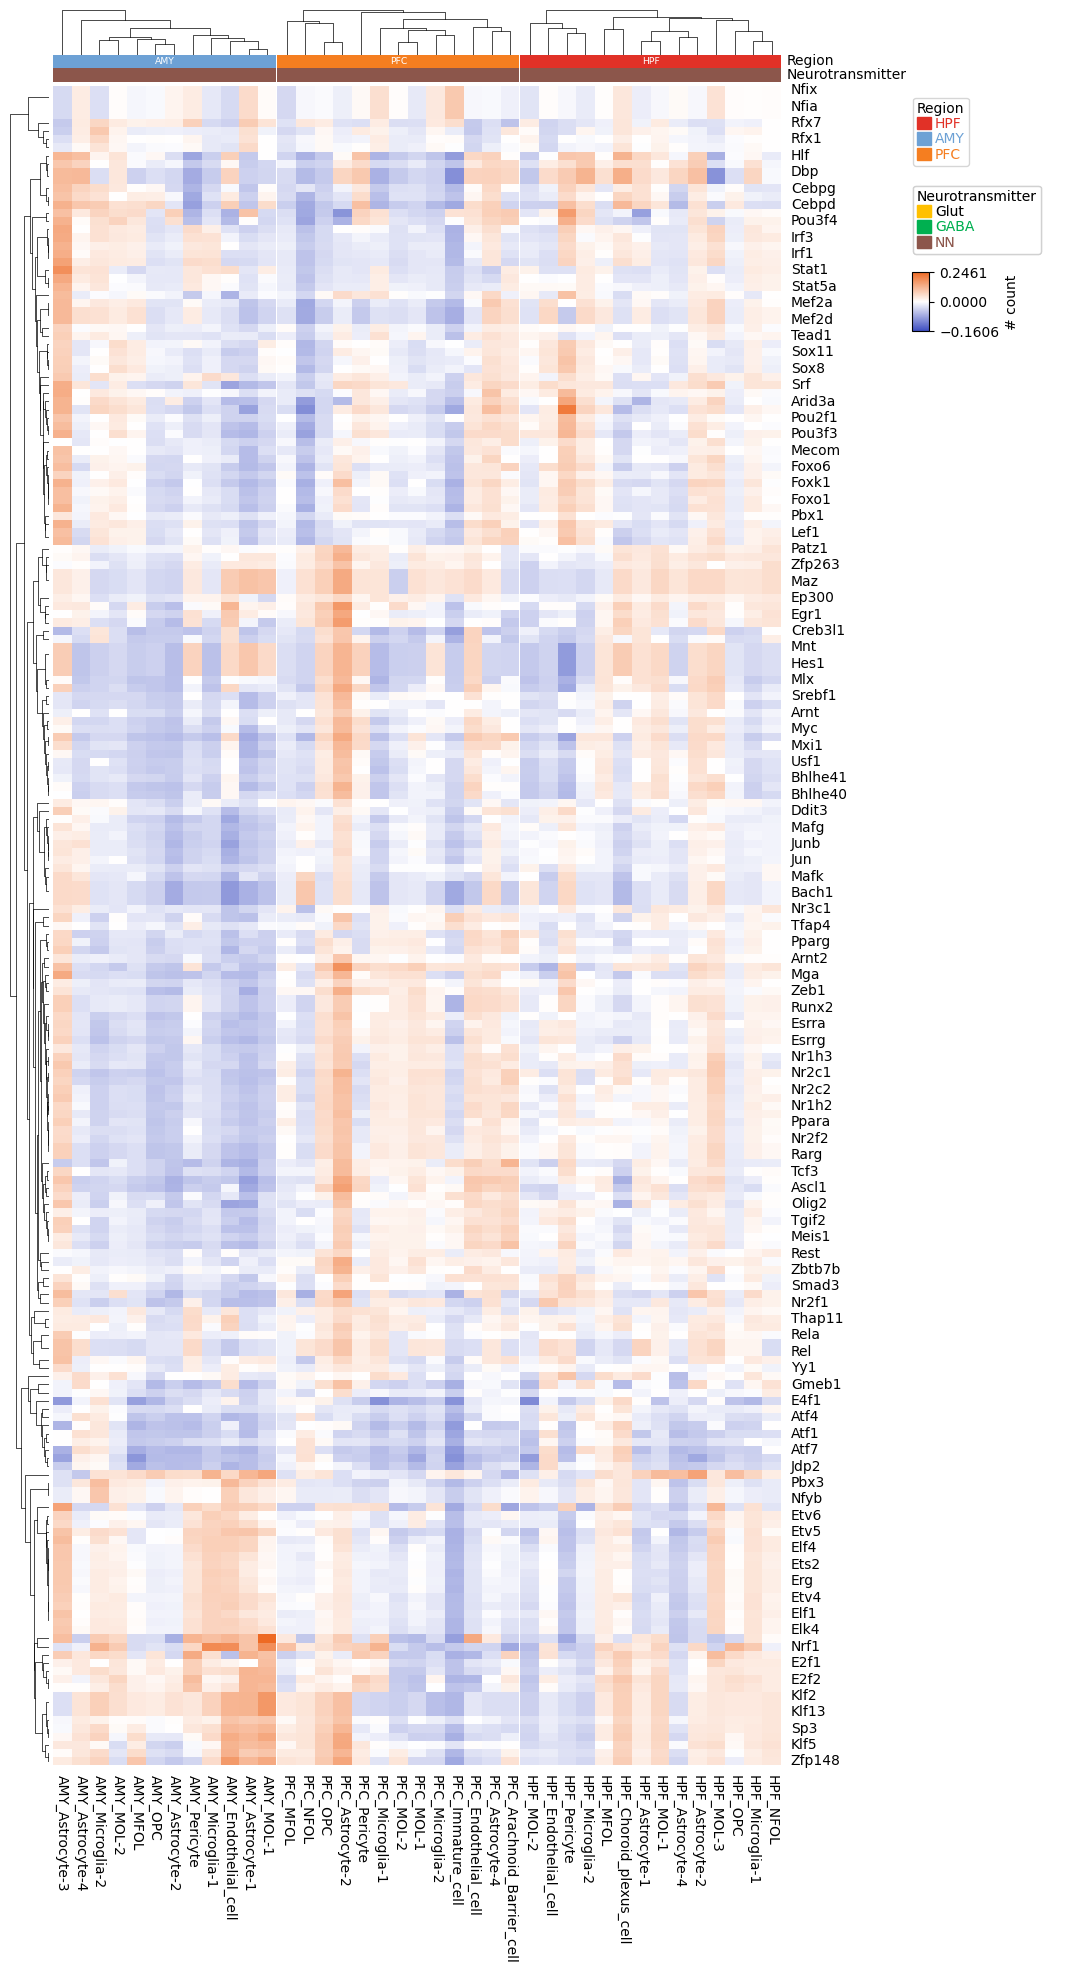

In [463]:
cm = draw_tf_heatmap(results[results.Neurotransmitter=='NN'],value_col="log2FC")

In [464]:
df_all_filtered_CUSUS = pd.read_csv('/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/scenicwil_tfs_fdr_log2fc0.csv')
df_3R = df_all_filtered_CUSUS[df_all_filtered_CUSUS['Region'].isin(['HPF','AMY','PFC'])]
df_3R['Region Subclass'] = df_3R['Region subclass']
df_3R['nlogp'] = -np.log10(df_3R['FDR'] + 1e-300) * np.sign(df_3R['log2FC'])
df_3R['Neurotransmitter'] = df_3R['Region Subclass'].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
df_3R['TF']= df_3R['TF'].str[:-3]

/tmp/ipykernel_3818014/2779743695.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_3R['Region Subclass'] = df_3R['Region subclass']
/tmp/ipykernel_3818014/2779743695.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_3R['nlogp'] = -np.log10(df_3R['FDR'] + 1e-300) * np.sign(df_3R['log2FC'])
/tmp/ipykernel_3818014/2779743695.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


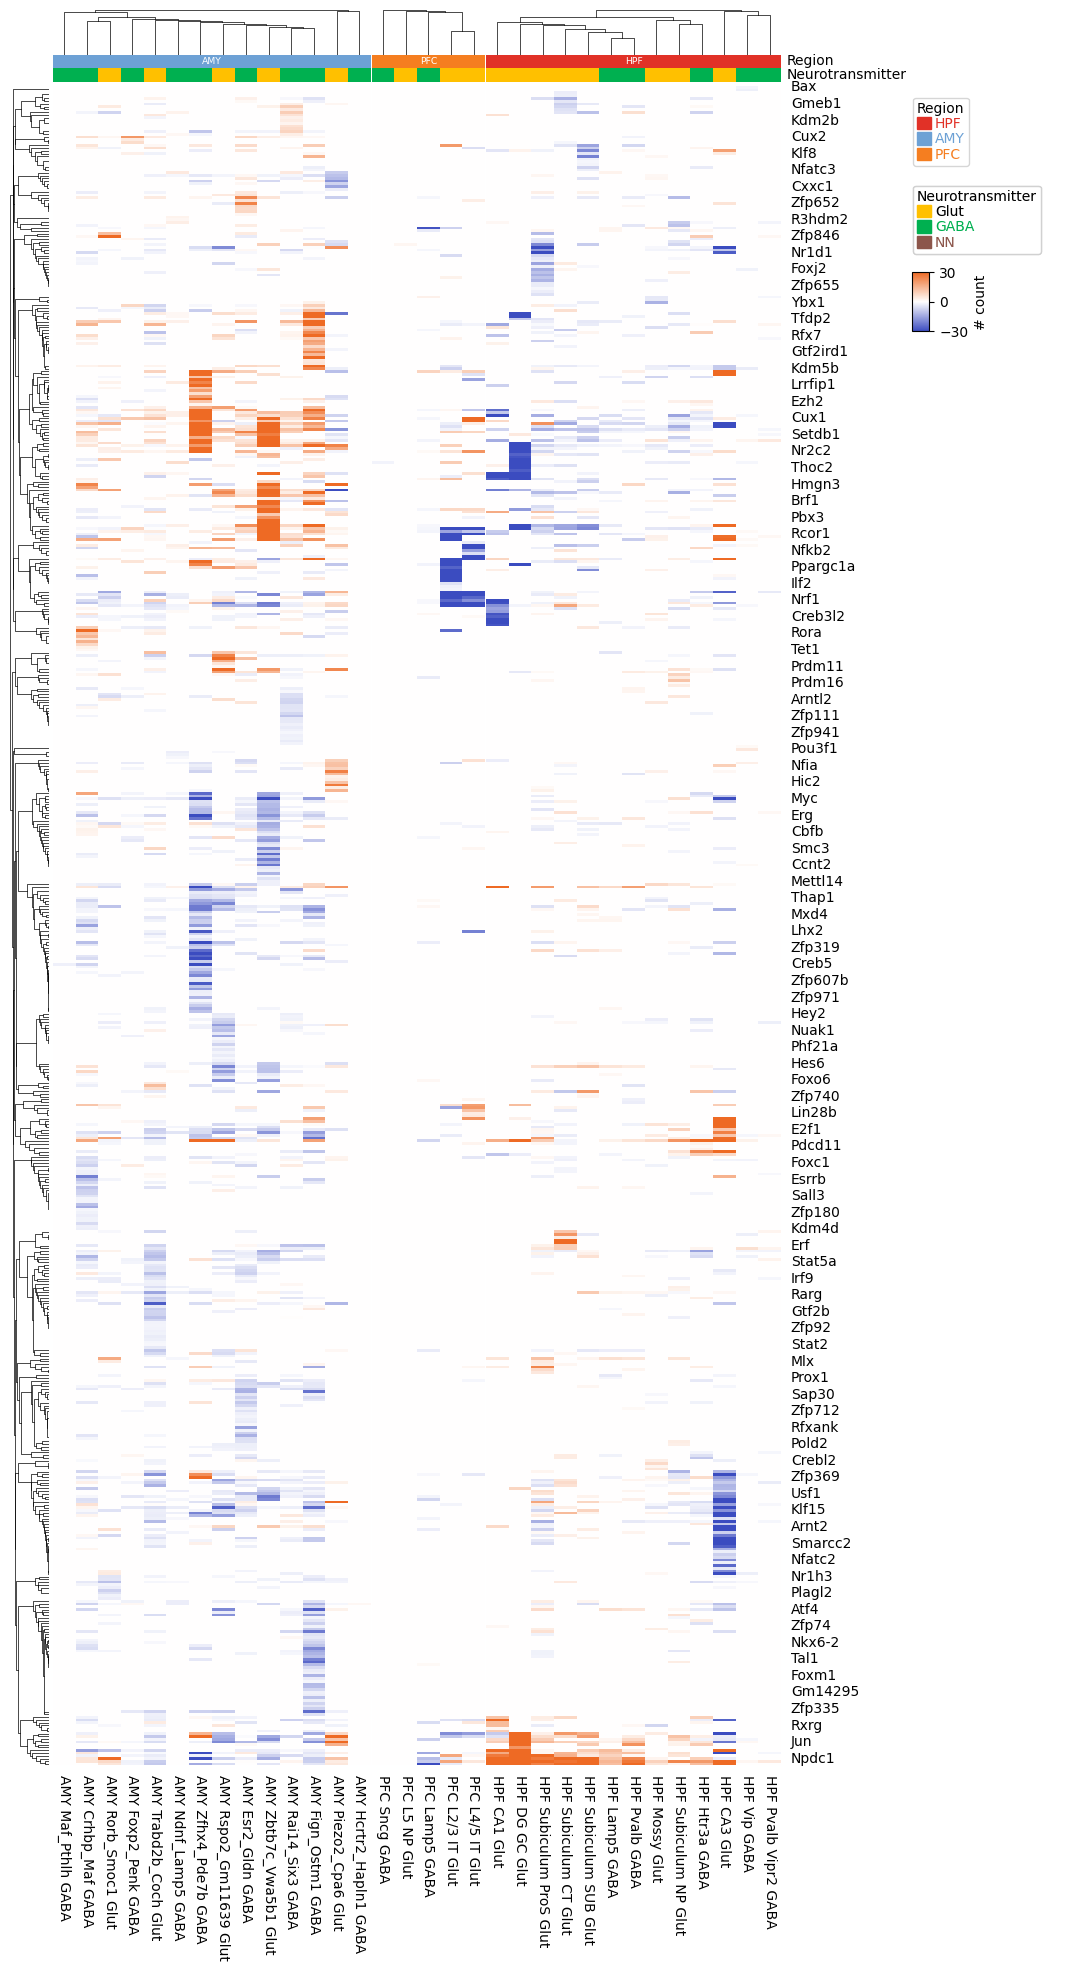

In [473]:
def draw_tf_heatmap_ordered(df,value_col="Regulation",row='TF',column='Region Subclass',
                            col_meta=['Region Subclass', 'Region', 'Neurotransmitter'],
                            clipping=10,row_order=None, col_order=None):
    df = df.copy()
    if clipping:
        df[value_col] = df[value_col].clip(-1*clipping,clipping)  
    
    if row_order is not None:
        df = df[df[row].isin(row_order)]
    if col_order is not None:
        df = df[df[column].isin(col_order)]
    # ============================
    # 1. 构建矩阵
    # ============================
    mat = df.pivot_table(
        index=row,
        columns=column,
        values=value_col,
        aggfunc="mean"
    ).fillna(0)
    print("Checking columns...")

    mat = mat.replace([np.inf, -np.inf], np.nan).fillna(0)
    mat = mat.astype(float)
    mat = mat.replace([np.inf, -np.inf], np.nan)
    mat = mat.fillna(0)
    mat = mat.apply(pd.to_numeric, errors="coerce").fillna(0)

    constant_cols = mat.columns[mat.apply(lambda x: x.nunique() <= 1)]
    print("Constant columns:", constant_cols.tolist())
    mat = mat.drop(columns=constant_cols)

    # # 2. Remove duplicate columns
    # mat_T = mat.T.drop_duplicates().T
    # removed_duplicates = set(mat.columns) - set(mat_T.columns)
    # print("Duplicate columns removed:", removed_duplicates)
    # mat = mat_T

    # 3. Final clean
    mat = mat.astype(float)
    assert np.isfinite(mat.values).all()

    # order the mat if row_order and col_order are provided
    if col_order is not None:
        # Only keep columns that exist
        col_order_filtered = [c for c in col_order if c in mat.columns]
        mat = mat[col_order_filtered]
    if row_order is not None:
        row_order_filtered = [r for r in row_order if r in mat.index]
        mat = mat.loc[row_order_filtered]
    # ============================
    # 2. 列注释 (Region + Neurotransmitter)
    # ============================
    col_meta = (
        df[["Region Subclass", "Region", "Neurotransmitter"]]
        .drop_duplicates()
        .set_index("Region Subclass")
        .loc[mat.columns]
    )

    # 按 region 排序列
    col_meta = col_meta.sort_values("Region")
    mat = mat[col_meta.index]
    region = col_meta["Region"]
    nt = col_meta["Neurotransmitter"]

    # ============================
    # 3. 行注释（可选：也可以不加）
    # ============================
    if "Category" in df.columns:
        row_meta = (
            df[["TF", "Category"]]
            .drop_duplicates()
            .set_index("TF")
            .loc[mat.index]
        )
        category = row_meta["Category"]
    else:
        category = None

    # ============================
    # 4. 创建顶部列注释
    # ============================
    col_ha = pch.HeatmapAnnotation(
        Region=pch.anno_simple(region, colors=region_colors, add_text=True),
        Neurotransmitter=pch.anno_simple(nt, colors=nt_colors, add_text=False),
        axis=1
    )
    # ============================
    # 5. 如果提供 Category，则加入左侧注释
    # ============================
    if category is not None:
        row_ha = pch.HeatmapAnnotation(
            Category=pch.anno_simple(category, add_text=False),
            axis=0
        )
    else:
        row_ha = None

    # ============================
    # 6. 颜色映射：蓝→白→橙，中心为0
    # ============================
    cmap = LinearSegmentedColormap.from_list(
        "blue_white_orange",
        ["#3B4CC0", "white", "#EE6A24"]
    )
    plt.figure(figsize=(10, 20))

    row_cluster = True if row_order is None else False
    col_cluster = True if col_order is None else False
    row_dendrogram = True if row_order is None else False
    col_dendrogram = True if col_order is None else False

    cm = pch.ClusterMapPlotter(
        data=mat,
        top_annotation=col_ha,
        left_annotation=row_ha,
        col_split=region,      # 按 Region 分面
        row_cluster=row_cluster,
        col_cluster=col_cluster,
        row_dendrogram=row_dendrogram,
        col_dendrogram=col_dendrogram,
        cmap=cmap,
        col_split_order = ['AMY','PFC','HPF'],
        center=0,
        show_rownames=True,
        show_colnames=True,
        label="# count",
        rasterized=True
    )
    plt.show()
    return cm

cm2 = draw_tf_heatmap_ordered(df_3R[df_3R.Neurotransmitter!='NN'],value_col="nlogp", clipping=30)

In [421]:
df_3R

,TF,scores,log2FC,pval,FDR,pct_nz_group,pct_nz_reference,comparison,Subclass,Region,Sex,Neurotransmitter,Direction,Gene,Gene_name,Ensemble,Region subclass,Region Subclass,nlogp
5,Ets2,17.452005,0.623999,3.323606e-68,9.505513e-66,1.000000,1.000000,CUSUS,MOL-2,AMY,F,NN,Up,Ets2(+),Ets2(+),Ets2(+),AMY MOL-2,AMY MOL-2,65.022024
6,Bmyc,13.413092,0.407593,5.068100e-41,2.415794e-39,1.000000,1.000000,CUSUS,MOL-2,AMY,F,NN,Up,Bmyc(+),Bmyc(+),Bmyc(+),AMY MOL-2,AMY MOL-2,38.616940
7,Thra,10.567341,1.511824,4.222970e-26,1.097972e-24,0.665644,0.347495,CUSUS,MOL-2,AMY,F,NN,Up,Thra(+),Thra(+),Thra(+),AMY MOL-2,AMY MOL-2,23.959409
8,Klf10,10.401607,0.548061,2.437869e-25,5.810254e-24,0.996933,0.998911,CUSUS,MOL-2,AMY,F,NN,Up,Klf10(+),Klf10(+),Klf10(+),AMY MOL-2,AMY MOL-2,23.235805
9,Gtf2f1,9.123649,0.295695,7.263701e-20,1.598014e-18,1.000000,1.000000,CUSUS,MOL-2,AMY,F,NN,Up,Gtf2f1(+),Gtf2f1(+),Gtf2f1(+),AMY MOL-2,AMY MOL-2,17.796419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11018,Foxp1,-9.354158,-0.227279,8.426752e-21,2.131968e-19,1.000000,1.000000,CUSUS,HPF Subiculum SUB Glut,HPF,M,Glut,Down,Foxp1(+),Foxp1(+),Foxp1(+),HPF Subiculum SUB Glut,HPF Subiculum SUB Glut,-18.671219
11019,Arntl,-9.456558,-0.183556,3.182468e-21,8.946271e-20,1.000000,1.000000,CUSUS,HPF Subiculum SUB Glut,HPF,M,Glut,Down,Arntl(+),Arntl(+),Arntl(+),HPF Subiculum SUB Glut,HPF Subiculum SUB Glut,-19.048358
11020,Jdp2,-9.679680,-0.312057,3.678647e-22,1.329568e-20,1.000000,1.000000,CUSUS,HPF Subiculum SUB Glut,HPF,M,Glut,Down,Jdp2(+),Jdp2(+),Jdp2(+),HPF Subiculum SUB Glut,HPF Subiculum SUB Glut,-19.876289
11021,Zmiz1,-9.750012,-0.134844,1.844460e-22,7.777471e-21,1.000000,1.000000,CUSUS,HPF Subiculum SUB Glut,HPF,M,Glut,Down,Zmiz1(+),Zmiz1(+),Zmiz1(+),HPF Subiculum SUB Glut,HPF Subiculum SUB Glut,-20.109162


Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexH

Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


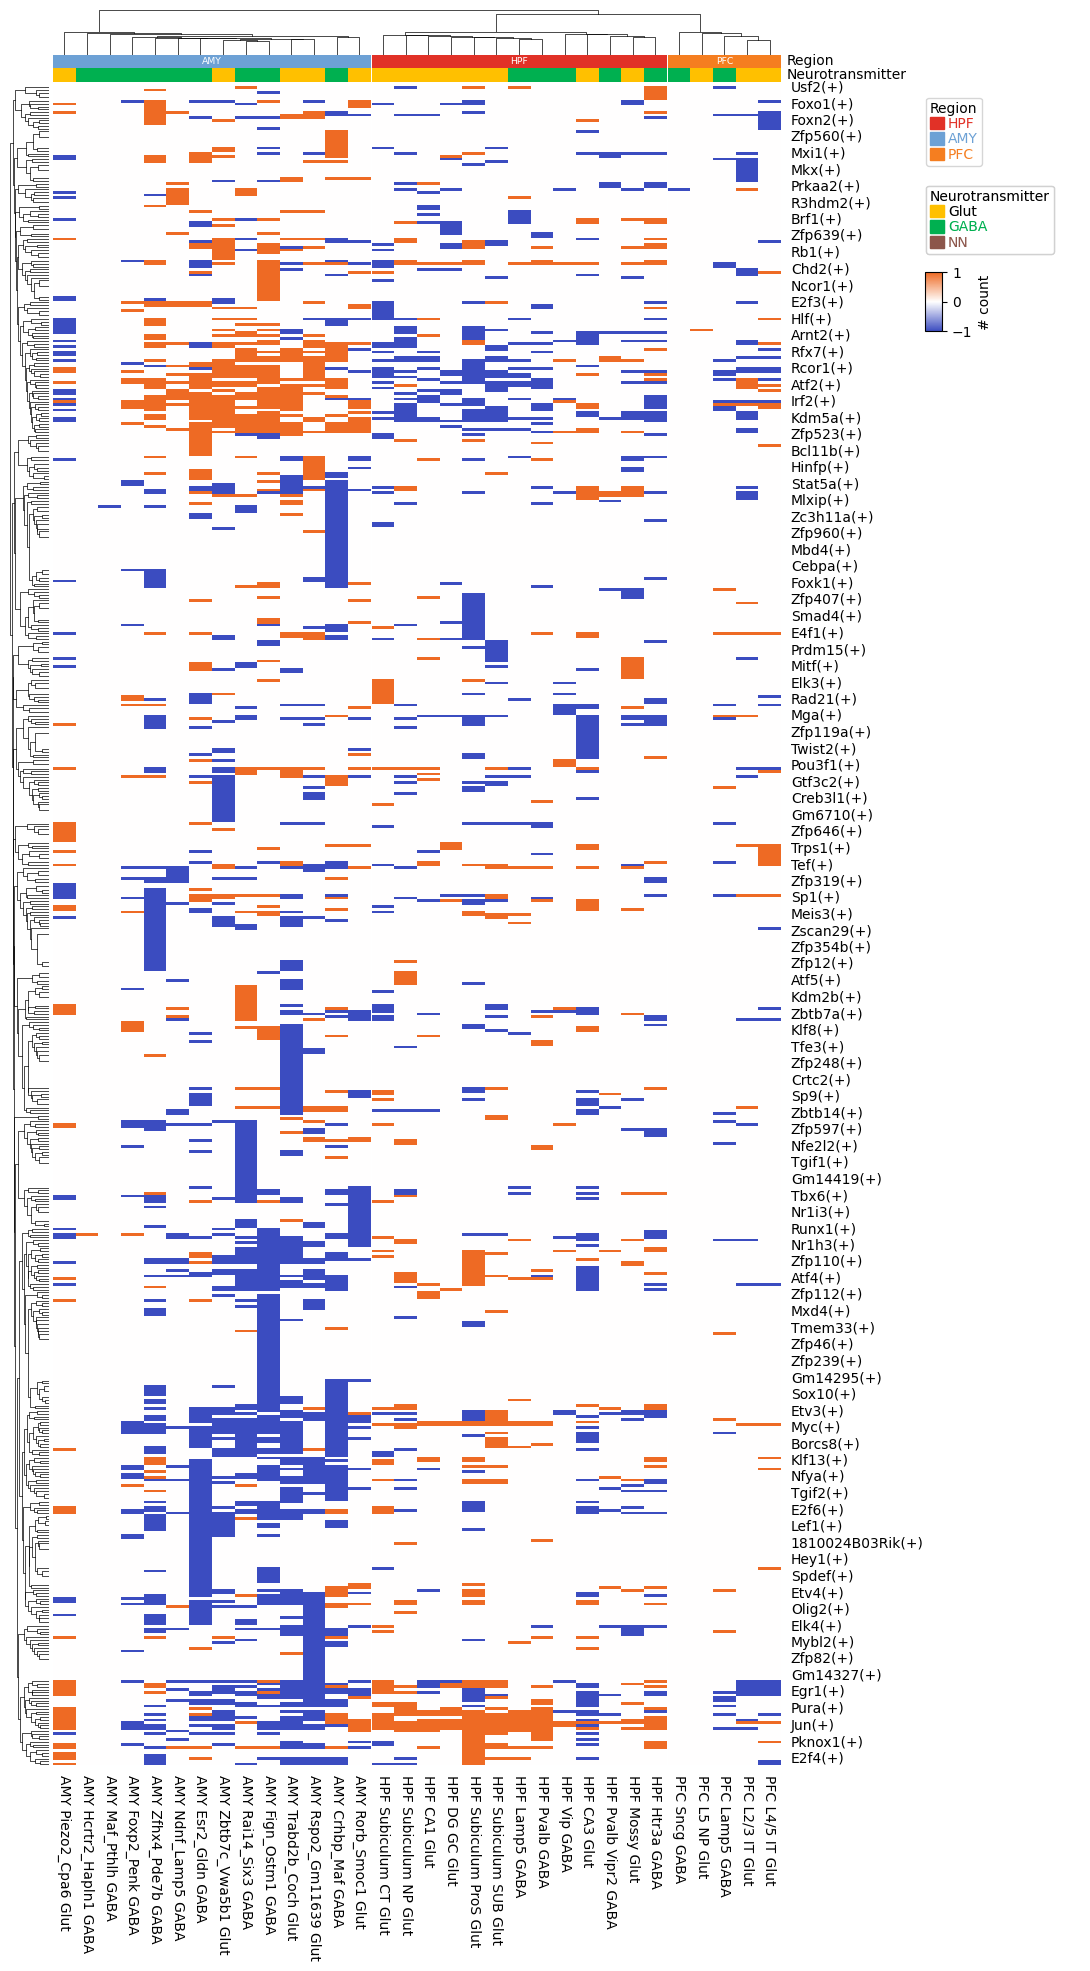

In [ ]:
cm = draw_tf_heatmap(df_3R[df_3R.Neurotransmitter!='NN'], value_col="nlogp", clipping=1)

In [238]:
df_tobias_drop = df_tobias.sort_values(by='abs_change',ascending=False).drop_duplicates(subset=['TFID'], keep='first')

In [223]:
df_tobias_drop = df_tobias_drop[~df_tobias_drop['name'].str.contains('meta')]

Text(0.5, 1.0, 'Motif Accessibility Volcano Plot (Top20 Up / Top20 Down)')

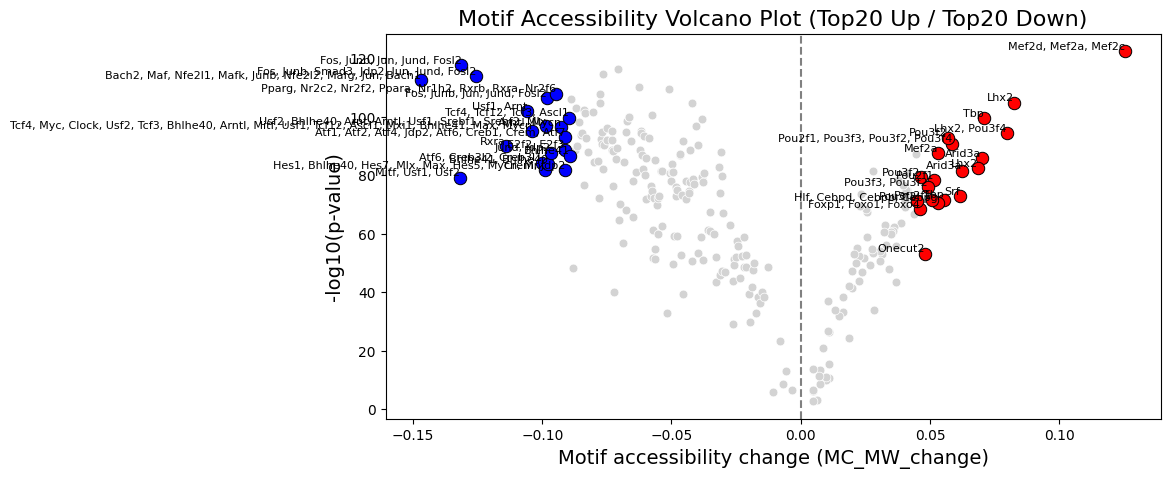

In [244]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# df = your TOBIAS BINDetect table
df_tobias_drop["neglog10_p"] = -np.log10(df_tobias_drop["MC_MW_pvalue"])

# ---- Top 20 UP (highest positive change) ----
top20_up = df_tobias_drop.nlargest(20, "MC_MW_change").copy()
top20_up["highlight"] = "up"

# ---- Top 20 DOWN (most negative change) ----
top20_down = df_tobias_drop.nsmallest(20, "MC_MW_change").copy()
top20_down["highlight"] = "down"

# ---- Combine top40 ----
top40 = pd.concat([top20_up, top20_down], axis=0)

# ---- Volcano plot ----
plt.figure(figsize=(10, 5))

# All background points (gray)
sns.scatterplot(
    data=df_tobias_drop,
    x="MC_MW_change",
    y="neglog10_p",
    color="lightgray",
    s=40
)

# Up 20 (red)
sns.scatterplot(
    data=top20_up,
    x="MC_MW_change",
    y="neglog10_p",
    color="red",
    s=80,
    edgecolor="black"
)

# Down 20 (blue)
sns.scatterplot(
    data=top20_down,
    x="MC_MW_change",
    y="neglog10_p",
    color="blue",
    s=80,
    edgecolor="black"
)

# ---- Add labels ----
for _, row in top40.iterrows():
    plt.text(
        row["MC_MW_change"],
        row["neglog10_p"],
        row["TF"],        # Your TF column name
        fontsize=8,
        ha="right",
        va="bottom"
    )

# ---- Axis + Style ----
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Motif accessibility change (MC_MW_change)", fontsize=14)
plt.ylabel("-log10(p-value)", fontsize=14)
plt.title("Motif Accessibility Volcano Plot (Top20 Up / Top20 Down)", fontsize=16)
